# Decision Tree Classification Model

Objective: Develop a Decision Tree Classification Model using the Seattle Weather Dataset to understand the full process of building, optimizing, and interpreting classification algorithms

In [20]:
from pathlib import Path
import pandas as pd

# Importar dataset
DATA_PATH = Path.cwd() / "seattle-weather-dataset.csv"

data = pd.read_csv(DATA_PATH)
df = pd.DataFrame(data)
df = df.drop(columns=['date']) # Ignorar esta columna, pues no será necesaria para el análisis

print("Sample data:")
df.head(4)

Sample data:


,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain
2,0.8,11.7,7.2,2.3,rain
3,20.3,12.2,5.6,4.7,rain


## 1. Identificar el equilibrio de clases del conjunto de datos

Es necesario identificar si el conjunto de datos está equilibrado o desequilibrado calculando la proporción de muestras en cada clase. 

En el caso de este dataset, se puede observar un **desequlibrio evidente**, pues la clase de "sun" y "rain" tienen un porcentaje alto respectivamente (de 43.81% y 43.87% respectivamente), mientras que el resto de las clases ("drizzle", "snow" y "fog") representan solo el 12.32% del resto del dataset, véase la información obtenida con el código para más detalles.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from collections import Counter

# Selección de solo las columnas numéricas del DataFrame para usar como variables predictoras
num_cols = df.select_dtypes(include='number').columns

# Definir la matriz de X (features) y la variable objetivo y
# X contiene todas las columnas numéricas, excepto la clase a predecir
# y contiene la columna "weather", que será la etiqueta del modelo
X = df[num_cols].copy()
y = df["weather"].copy()

"""
Obtener información relevante
"""

# Muestra la forma del dataset original y de los conjuntos creados
print("---- Forma del dataset original ----")
print("df:", df.shape)
print("X:", X.shape)

# Muestra las columnas que se usarán como entrada del modelo
print("\nColumnas:")
print(X.columns.tolist())

# Muestra el tipo de dato de cada columna para verificar el tipo de datos que manejan
print("\nTipos:")
print(X.dtypes)

# Muestra la distribución original de las clases para detectar si el dataset está balanceado
class_counts = Counter(y)
total = len(y)

print("\nOriginal class distribution (count):", class_counts)
print("\nOriginal class distribution (%):")
for label, count in class_counts.items():
    pct = (count / total) * 100
    print(f"{label}: {count} ({pct:.2f}%)")



---- Forma del dataset original y datos de entrenamiento y prueba ----
df: (1461, 5)
X: (1461, 4)

Columnas:
['precipitation', 'temp_max', 'temp_min', 'wind']

Tipos:
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
dtype: object

Original class distribution (count): Counter({'rain': 641, 'sun': 640, 'fog': 101, 'drizzle': 53, 'snow': 26})

Original class distribution (%):
drizzle: 53 (3.63%)
rain: 641 (43.87%)
sun: 640 (43.81%)
snow: 26 (1.78%)
fog: 101 (6.91%)


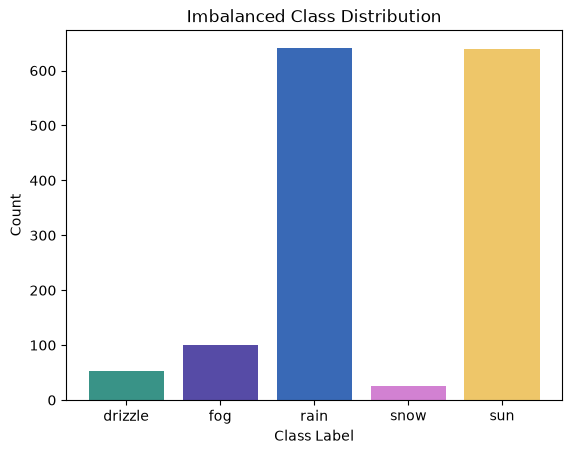

In [37]:
# Graficar la distribución de clases
classes, counts = np.unique(y, return_counts=True)

colors_classes = ["#399387", "#564BA6", "#3969B6", "#D281D2", "#EEC669"]

plt.figure()
plt.bar(classes, counts, color=colors_classes)

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Imbalanced Class Distribution")
plt.xticks(classes)
plt.show()

## 2. Mitigación del desequilibrio

Con el fin de mitigar los problemas de ajuste insuficiente o sobreajuste debido al desbalance del dataset, se deben de aplicar técnicas apropiadas para abordarlo, ya sea a través de un sobremuestreo o un muestreo insuficiente. 

En este caso, el enfoque es de: oversampling. Con ello se busca igual la cantidad de muestras de cada clase con la de

In [44]:
from sklearn.utils import resample
import pandas as pd
import plotly.express as px

# Buscar la clase con más datos en la columna 'weather' y guardar el valor máximo 
max_count = df['weather'].value_counts().max()

# Separar el DataFrame por clase y sobremuestrear cada grupo
# hasta alcanzar el número de muestras de la clase mayoritaria.
balanced_parts = [
    resample(
        group,
        replace=True,
        n_samples=max_count,
        random_state=42
    )
    for _, group in df.groupby("weather")
]

# Unir todas las clases balanceadas, mezclar las filas
# y restablecer el índice del nuevo DataFrame.
balanced_df = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Definir nuevos objetivos con base en los cambios realizados
X = balanced_df[num_cols].copy()
y = balanced_df["weather"].copy()

# ----------------------------- #
# Obtener información relevante #
# ----------------------------- #

# Muestra la forma del dataset oversampled y de los conjuntos creados
print("---- Forma del dataset oversampled y datos de entrenamiento y prueba ----")
print("Balanced df:", balanced_df.shape)

# Muestra las columnas que se usarán como entrada del modelo
print("\nColumnas:")
print(X.columns.tolist())

# Muestra el tipo de dato de cada columna para verificar el tipo de datos que manejan
print("\nTipos:")
print(X.dtypes)

# Muestra la distribución original de las clases para detectar si el dataset está balanceado
class_counts = Counter(y)
total = len(y)

print("\nBalanced class distribution (count):", class_counts)
print("\nBalanced class distribution (%):")
for label, count in class_counts.items():
    pct = (count / total) * 100
    print(f"{label}: {count} ({pct:.2f}%)")


---- Forma del dataset oversampled y datos de entrenamiento y prueba ----
Balanced df: (3205, 5)

Columnas:
['precipitation', 'temp_max', 'temp_min', 'wind']

Tipos:
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
dtype: object

Balanced class distribution (count): Counter({'drizzle': 641, 'sun': 641, 'snow': 641, 'rain': 641, 'fog': 641})

Balanced class distribution (%):
drizzle: 641 (20.00%)
sun: 641 (20.00%)
snow: 641 (20.00%)
rain: 641 (20.00%)
fog: 641 (20.00%)


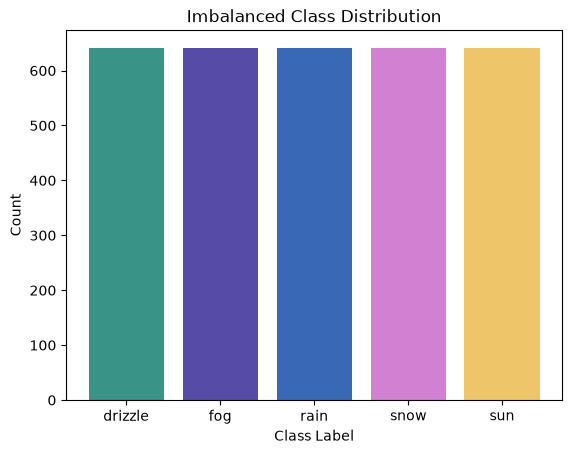

In [45]:
# Graficar la distribución de clases balanceadas
classes, counts = np.unique(y, return_counts=True)

plt.figure()
plt.bar(classes, counts, color=colors_classes)

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Imbalanced Class Distribution")
plt.xticks(classes)
plt.show()

## 3. Preparar datos para el modelado

In [ ]:
# Definir features y target
num_cols = balanced_df.select_dtypes(include='number').columns
X = balanced_df[num_cols].copy()
y = balanced_df['weather'].copy()

print("Features:", X.columns.tolist())
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Dividir set de entrenamiento y de testeo (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Features: ['precipitation', 'temp_max', 'temp_min', 'wind']
Features shape: (3205, 4)
Target shape: (3205,)

Training set size: 2243
Testing set size: 962


## 4. Construcción de un Decision Tree Classifier básico

Para esta sección se utilizan las configuraciones default del classifier, o sea, no hay ninguna optimización de hiperparámetros.

Modelo base: DECISION TREE SIMPLE

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.93      1.00      0.96       193
         fog       0.93      0.99      0.96       192
        rain       0.99      0.94      0.97       192
        snow       0.99      1.00      1.00       193
         sun       0.96      0.86      0.91       192

    accuracy                           0.96       962
   macro avg       0.96      0.96      0.96       962
weighted avg       0.96      0.96      0.96       962


Accuracy: 0.9605


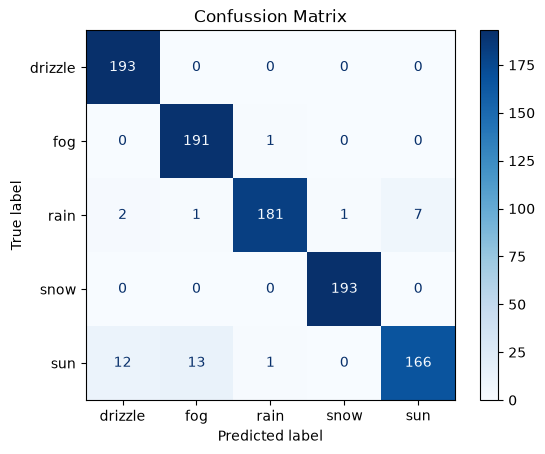

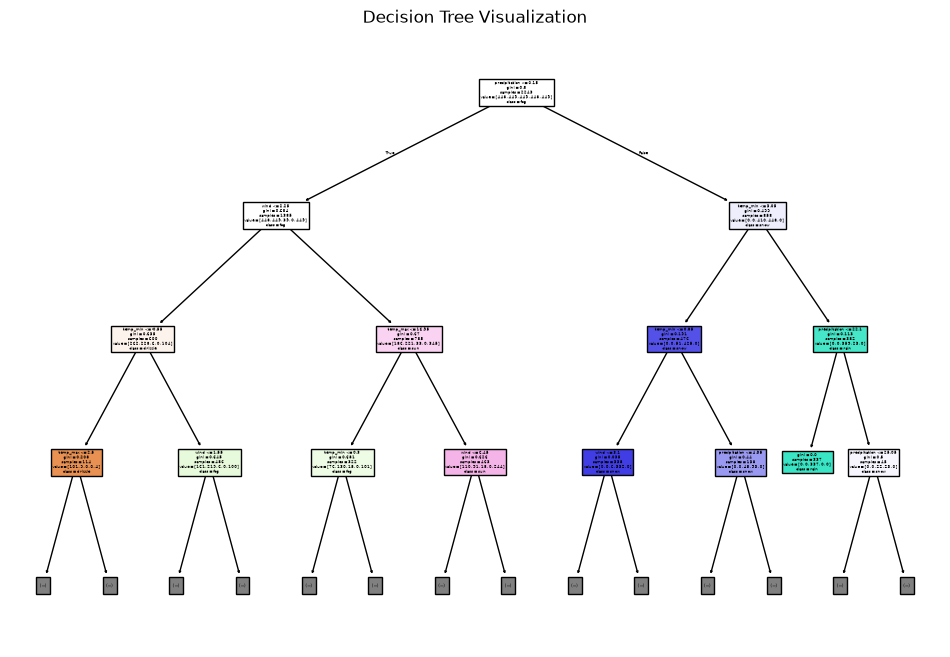

Tree depth: 17
Number of leaves: 240
Number of nodes: 479


In [51]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

dtree_inicial = DecisionTreeClassifier()
dtree_inicial.fit(X_train, y_train)
y_pred_inicial = dtree_inicial.predict(X_test)

# Evaluate the model
print("Modelo base: DECISION TREE SIMPLE")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_inicial))

# Accuracy
accuracy_initial = accuracy_score(y_test, y_pred_inicial)
print(f"\nAccuracy: {accuracy_initial:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_inicial, labels=dtree_inicial.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree_inicial.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confussion Matrix")
plt.show()
plt.figure(figsize=(12, 8))

# Árbol de decisiones
plot_tree(dtree_inicial, feature_names=X.columns, class_names=dtree_inicial.classes_, filled=True, max_depth=3)
plt.title("Decision Tree Visualization")
plt.show()

print(f"Tree depth: {dtree_inicial.get_depth()}")
print(f"Number of leaves: {dtree_inicial.get_n_leaves()}")
print(f"Number of nodes: {dtree_inicial.tree_.node_count}")

Los resultados de este árbol demuestran que el árbol es bueno al clasificar los tipos de clima (con un accuracy de 95.84%). Básicamente, la cantidad de clasificaciones correctas es positiva y demuestra que se pueden confiar en las predicciones del modelo. Aunque es importante mencionar que este resultado es a nivel global y que, de manera individual (por clase), los resultados son diferentes. Por ejemplo, el modelo reconoce peor el sun (con un recall de 0.88), mientras que el desempeño para clasificar snow es alto (con F1 = 0.99). Esto indica que el modelo tiene algunos problemas de clasificación, sin embargo, al observar la matriz de confusión es posible observar que son mínimos y que, como ya se dijo, en general hace un buen trabajo.

## 5. Construcción de un Decision Tree Classifier con hiperparámetros

Para esta sección se utilizan hiperparámetros diferentes para buscar la combinación más óptima con el fin de obtener un mejor resultado/modelo.

In [59]:
from sklearn.model_selection import train_test_split, GridSearchCV

"""
HYPERPARAMETER OPTIMIZATION WITH GridSearchCV
"""
# Setting de hiperparámetros para el árbol
param_grid = {
    'max_depth': [3, 5, 10, 25, 30, None], # Define la profunidad del árbol
    'min_samples_split': [2, 5, 10, 20], # Cantidad mínima de divisiones
    'min_samples_leaf': [1, 2, 4, 10], # Número mínimo de muestras que debe tener un nodo hoja
    'max_features': [None, 'sqrt', 'log2'], # Número máximo de features que se deben de evaluar para encontrar el mejor split de cada nodo
    'max_leaf_nodes': [None, 10, 20, 50, 100], # Número máximo de hojas
    'criterion': ['gini', 'entropy']
}

dtree_grid = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    dtree_grid, 
    param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy', 
    n_jobs=1) 

# Ejecutar grid search
print("Ejecución de Grid Search para optimización de parámetros...")
print(f"Total de combinaciones de parámetros: {len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['max_features']) * len(param_grid['max_leaf_nodes'])}")
grid_search.fit(X_train, y_train)

# Display de resultados
print(f"\nMejores hiperparámetros:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMejor precisión de cross-validation: {grid_search.best_score_:.4f}")

Ejecución de Grid Search para optimización de parámetros...
Total de combinaciones de parámetros: 1440

Mejores hiperparámetros:
  criterion: entropy
  max_depth: 25
  max_features: sqrt
  max_leaf_nodes: None
  min_samples_leaf: 1
  min_samples_split: 2

Mejor precisión de cross-validation: 0.9518


Después de ejecutar la búsqueda de hiperparámetros, se pudo obtener **la combinación óptima de hiperparámetros para el modelo de árbol de decisión**. El criterio que obtuvo mejores resultados fue **entropy**, que mide la ganancia de información y resultó más efectivo que gini para este conjunto de datos balanceado. 

La profundidad máxima se estableció en 25, permitiendo que el árbol capturara patrones complejos sin llegar a realizar un overfitting, mientras que el parámetro `max_features='sqrt'` ayudó a reducir la varianza y el sobreajuste al limitar las opciones de división. Los parámetros `min_samples_leaf=1` y `min_samples_split=2` permiten crear hojas y divisiones con pocas muestras, como resultado es posible encontrar patrones específicos de clases más pequeñas. Finalmente, `max_leaf_nodes=None` deja que el árbol crezca según la restricción de los demás parámetros.

In [55]:
# Train optimized model
dtree_optimized = grid_search.best_estimator_
y_pred_optimized = dtree_optimized.predict(X_test)

# Evaluate optimized model
print("Modelo mejorado: DECISION TREE CON OPTIMIZACIÓN DE PARÁMETROS")

# Classification report
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_optimized))

# Accuracy
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"\nAccuracy: {accuracy_optimized:.4f}")

Modelo mejorado: DECISION TREE CON OPTIMIZACIÓN DE PARÁMETROS

Reporte de clasificación:
              precision    recall  f1-score   support

     drizzle       0.97      1.00      0.99       193
         fog       0.91      0.99      0.95       192
        rain       0.99      0.94      0.97       192
        snow       0.99      1.00      1.00       193
         sun       0.95      0.88      0.91       192

    accuracy                           0.96       962
   macro avg       0.96      0.96      0.96       962
weighted avg       0.96      0.96      0.96       962


Accuracy: 0.9626


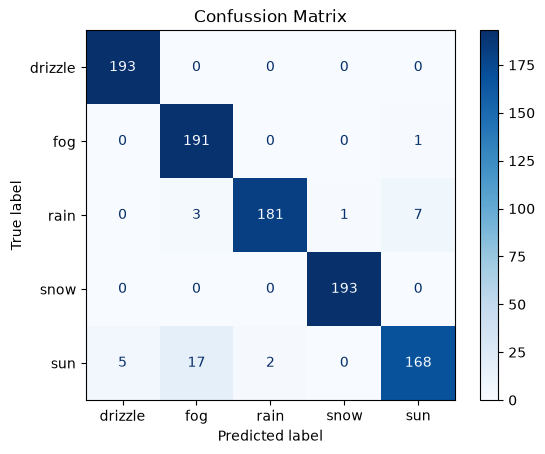

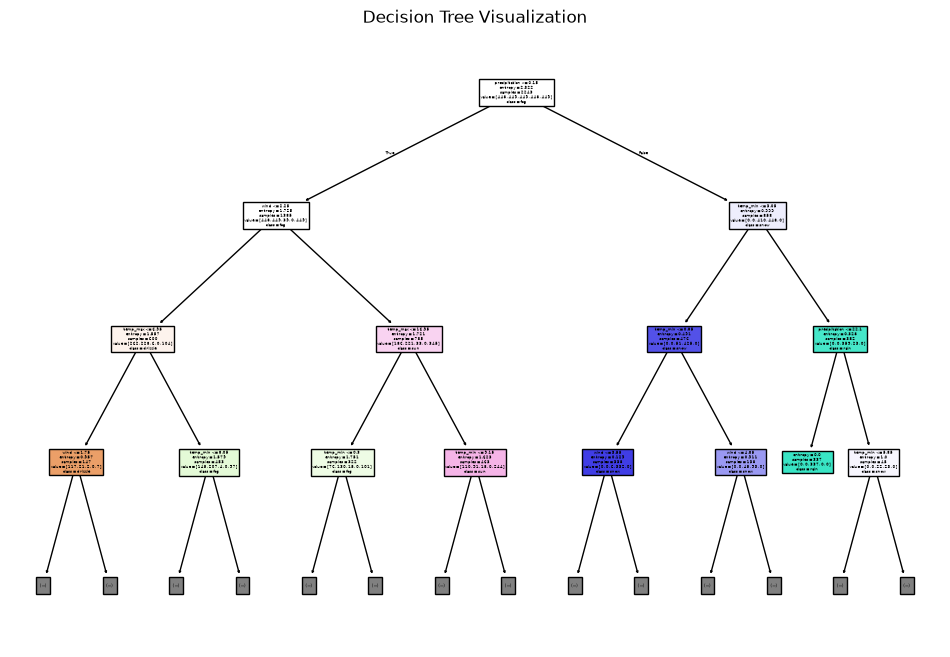

         Feature  Importance
0  precipitation    0.400206
2       temp_min    0.255228
3           wind    0.181092
1       temp_max    0.163475


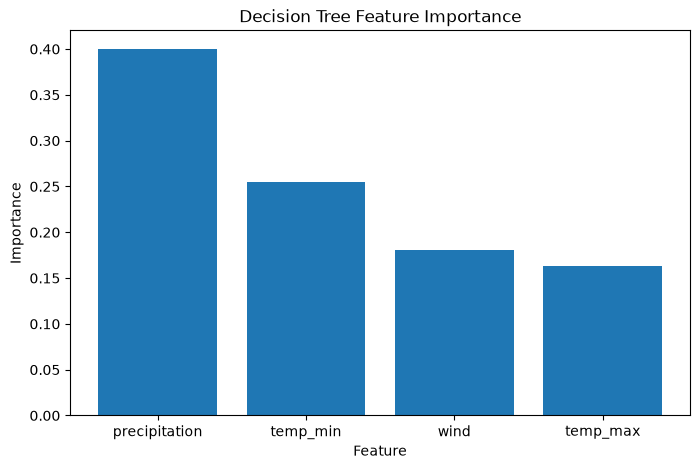

              precision    recall  f1-score   support

     drizzle       0.97      1.00      0.99       193
         fog       0.91      0.99      0.95       192
        rain       0.99      0.94      0.97       192
        snow       0.99      1.00      1.00       193
         sun       0.95      0.88      0.91       192

    accuracy                           0.96       962
   macro avg       0.96      0.96      0.96       962
weighted avg       0.96      0.96      0.96       962

Tree depth: 19
Number of leaves: 263
Number of nodes: 525


In [57]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_optimized, labels=dtree_optimized.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree_optimized.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confussion Matrix")
plt.show()
plt.figure(figsize=(12, 8))

# Árbol de decisiones
plot_tree(dtree_optimized, feature_names=X.columns, class_names=dtree_optimized.classes_, filled=True, max_depth=3)
plt.title("Decision Tree Visualization")
plt.show()

feature_importance = pd.DataFrame({'Feature': X.columns, "Importance": dtree_optimized.feature_importances_}) # Create a DataFrame containing each predictor and its in
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance)
plt.figure(figsize=(8,5))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.show()
print(classification_report(y_test, y_pred_optimized, labels=dtree_optimized.classes_))

print(f"Tree depth: {dtree_optimized.get_depth()}")
print(f"Number of leaves: {dtree_optimized.get_n_leaves()}")
print(f"Number of nodes: {dtree_optimized.tree_.node_count}")

# Análisis comparativo

Al realizar una comparación de ambos modelos, es posible observar diferencias significativas en diferentes aspectos. Por ejemplo, en términos de precisión, el modelo optimizado logra un 96.26% a comparación del 96.05% del modelo base. Es importante destacar que esta mejora viene acompañada de una menor interpretabilidad, ya que el árbol optimizado tiene 19 niveles de profundidad y 263 hojas, comparado con los 17 niveles y 240 hojas del modelo base, por lo que su lectura visual es más compleja.

En cuanto al sobreajuste, el modelo optimizado presenta un mayor riesgo debido a su complejidad incrementada, aunque se utiliza `sqrt`para evitar este problema como se mencionó anteriormente. Además, el costo computacional es significativamente mayor en el modelo optimizado, pues este evalúa 1,440 combinaciones de parámetros mediante validación cruzada, mientras que el modelo base se entrenó rápidamente con los valores por defecto. Por otro lado, en cuanto a los resultados de rendimiento por clase, es posible notar que la optimización mejoró notablemente la clasificación de "drizzle" (F1-score de 0.96 a 0.99), mientras que las demás clases mantuvieron un rendimiento similar. 

En resumen, aunque la optimización de hiperparámetros ofrece una ligera mejora en precisión, esta viene con el costo de una mayor complejidad computacional y menor interpretabilidad. Para este dataset en particular, el modelo sin optimización funciona bien, por lo que no es necesario optar por una optimización que sacrifica interpretabilidad y tiempo de cómputo.